# Week 1 — Homework: EHR Data Extraction & Quality Assessment

In this assignment, you will build a **clinical note extraction pipeline** and perform **data quality assessment** on a synthetic EHR dataset. The dataset contains:

- **Patient demographics**: Basic patient information (age, gender, race)
- **Clinical encounters**: Hospital visits, outpatient appointments, emergency visits
- **Conditions/Diagnoses**: ICD-coded medical conditions including diabetes
- **Medications**: Prescribed drugs with start/stop dates
- **Observations**: Lab values (HbA1c, glucose) and vital signs (BP, weight)
- **Clinical notes**: Unstructured text containing additional clinical information

> **Note on Assignment Length:** This homework may look long, but don't worry! You have **4 weeks** to complete it. The required sections (A & B) are the priority — the optional sections (C & D) are there for deeper exploration if you have time. Work through it step by step at your own pace.

### Why This Assignment Matters

In real healthcare systems, **up to 80% of clinical information** exists only in unstructured text (clinical notes, discharge summaries, radiology reports). The structured tables (CSV files) we work with often have **missing encounters** because:

1. Not all encounters are coded properly at time of care
2. Some information is only documented in free-text notes
3. Data integration across systems is incomplete

Your goal is to **extract structured data from clinical notes** to fill these gaps, and **assess data quality** before building ML models in Week 2.

---

## Deliverables

You should complete:

1. **Section A (Required)**: Understand the `ExtendedPatientProfile` class and create sample profiles
2. **Section B (Required)**: Build extraction functions and process clinical notes in batch
3. **Section C (Optional)**: Extended data exploration with visualizations
4. **Section D (Optional)**: Data quality assessment with summary report

---

## What You'll Learn

| Skill | Application |
|-------|-------------|
| **Regex patterns** | Extract dates, vitals, labs from unstructured text |
| **Temporal safety** | Prevent data leakage in ML feature engineering |
| **Data quality assessment** | Identify gaps before model building |
| **Pipeline thinking** | Build reusable, composable extraction functions |

## Setting Environment Up for Colab

Mount Google Drive and configure paths so this notebook can find the repository and the dataset.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Set your Google Drive path here
# Replace <PATH_TO_REPO> with your actual repository path
REPO_PATH = "/content/drive/MyDrive/MASAID/AI_Project_Group/EHR/repo"

# Data directory (cleaned data from Part 2)
DATA_DIR = f"{REPO_PATH}/data/week_1/cleaned_data"

# Output directory (processed data)
OUTPUT_DIR = f"{REPO_PATH}/data/week_1/processed_data"

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: /content/drive/MyDrive/MASAID/AI_Project_Group/EHR/repo/data/week_1/cleaned_data
Output directory: /content/drive/MyDrive/MASAID/AI_Project_Group/EHR/repo/data/week_1/processed_data


---

## Setup: Import Libraries and Load Data

Before diving into the analysis, we need to set up our environment.

| Library | Purpose |
|---------|---------|
| **pandas** | Data manipulation and analysis |
| **numpy** | Numerical operations |
| **matplotlib/seaborn** | Visualizations |
| **re** | Regular expressions for text extraction |

We'll load the **cleaned data** from Part 2.

In [3]:
# (provided)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
# (provided)
# Load cleaned data from Part 2
# CSVs are in cleaned_data/csv/, notes are in cleaned_data/
patients = pd.read_csv(os.path.join(DATA_DIR, "csv", "patients.csv"))
encounters = pd.read_csv(os.path.join(DATA_DIR, "csv", "encounters.csv"))
conditions = pd.read_csv(os.path.join(DATA_DIR, "csv", "conditions.csv"))
medications = pd.read_csv(os.path.join(DATA_DIR, "csv", "medications.csv"))
observations = pd.read_csv(os.path.join(DATA_DIR, "csv", "observations.csv"))
procedures = pd.read_csv(os.path.join(DATA_DIR, "csv", "procedures.csv"))
allergies = pd.read_csv(os.path.join(DATA_DIR, "csv", "allergies.csv"))

tables = {
    'patients': patients,
    'encounters': encounters,
    'conditions': conditions,
    'medications': medications,
    'observations': observations,
    'procedures': procedures,
    'allergies': allergies
}

print("All tables loaded:")
for name, df in tables.items():
    print(f"  {name}: {len(df):,} rows")

All tables loaded:
  patients: 9,998 rows
  encounters: 73,544 rows
  conditions: 31,589 rows
  medications: 25,190 rows
  observations: 345,083 rows
  procedures: 37,287 rows
  allergies: 2,739 rows


In [5]:
# (provided)
def get_col(df, name):
    """Find column by name, case-insensitive."""
    for col in df.columns:
        if col.lower() == name.lower():
            return col
    return None

print("get_col helper function defined")

get_col helper function defined


---

# Section A: ExtendedPatientProfile (Required)

## Why This Section Matters

For **ML risk prediction** on patient data, we need more than just static patient information. We need:

| Capability | Why It's Needed |
|------------|------------------|
| **Sorted timelines** | Events must be ordered chronologically for time-series analysis |
| **Feature computation at any time point** | "What features would we compute on 2020-01-15?" |
| **Temporal safety** | Features must only use data from BEFORE the prediction date (no data leakage!) |
| **Risk labeling** | "Did a high-risk event occur in the next 30 days?" |

The `ExtendedPatientProfile` class provides all of these capabilities. It extends the base `PatientProfile` with:

- **HbA1c timeline**: Sorted list of HbA1c readings with dates
- **Encounter timeline**: Sorted list of encounters (outpatient, emergency, inpatient)
- **Medication timeline**: Changes in medications over time
- **Diabetes profile**: Structured summary of diabetes-related information

> **Note:** Understanding this class is essential for Week 2, where you'll implement the `get_daily_features(cutoff_time)` method for risk prediction.

## A.1: Key Concept - Temporal Safety (cutoff_time)

When building ML models on time-series patient data, **data leakage** is a critical problem to avoid.

### What is Data Leakage?

Data leakage occurs when your model has access to information it wouldn't have at prediction time. For example:

- You're predicting whether a patient will have a complication in the **next 30 days**
- But your features include lab values from those 30 days (the future!)
- The model learns to "cheat" by using future information

### The Solution: cutoff_time

Every feature computation must accept a `cutoff_time` parameter and only use data from **before** that time.

**Wrong approach (data leakage):**
```python
# BAD: Uses ALL HbA1c readings, including future ones!
def get_max_hba1c(profile):
    return max(r['value'] for r in profile.hba1c_timeline)
```

**Correct approach (temporal safety):**
```python
# GOOD: Only uses readings BEFORE cutoff_time
def get_max_hba1c(profile, cutoff_time):
    past_readings = [r for r in profile.hba1c_timeline if r['date'] < cutoff_time]
    return max(r['value'] for r in past_readings) if past_readings else None
```

In **Week 2**, all features you implement in `get_daily_features(cutoff_date)` must follow this pattern.

In [6]:
# (provided)
# Import ExtendedPatientProfile from the src directory
import sys
sys.path.insert(0, f'{REPO_PATH}/src')

from profiles.extended_patient_profile import ExtendedPatientProfile

print("ExtendedPatientProfile imported")
print("Review src/profiles/extended_patient_profile.py to understand the timeline attributes and add_* methods")

ExtendedPatientProfile imported
Review src/profiles/extended_patient_profile.py to understand the timeline attributes and add_* methods


## Task A.2: Create and Populate an ExtendedPatientProfile

Now it's your turn to practice using the `ExtendedPatientProfile` class.

### Aim
Create an ExtendedPatientProfile for a sample diabetic patient and populate it with:
- Basic demographics
- Medical conditions (diabetes, hypertension)
- HbA1c readings over time
- Encounter events (outpatient visits, emergency visits)

### Plan
1. Create an `ExtendedPatientProfile` with patient ID and demographics dict
2. Add conditions using `add_condition()`
3. Add HbA1c readings using `add_hba1c_reading(datetime, value)`
4. Add encounters using `add_encounter_event(datetime, type, description)`
5. Print summaries to verify the profile is correctly populated

### Expected Outcome
- Profile shows the patient has diabetes
- HbA1c timeline contains 4 readings
- Encounter timeline contains 3 events

In [7]:
# Create a sample patient profile
# We'll create a 64-year-old male patient with Type 2 Diabetes and Hypertension

sample_demographics = {
    'gender': 'M',
    'birthdate': '1960-05-15',
    'race': 'white'
}

profile = ExtendedPatientProfile('sample-patient-001', sample_demographics)

# Add conditions - the patient has Type 2 Diabetes (diagnosed 2015) and Hypertension (diagnosed 2010)
profile.add_condition({'description': 'Type 2 Diabetes', 'onset': '2015-01-10'})
profile.add_condition({'description': 'Hypertension', 'onset': '2010-03-20'})


# Add HbA1c readings to timeline
# These readings show the patient's diabetes control over 2020
# HbA1c < 7% is good control, 7-9% is suboptimal, > 9% is poor control
profile.add_hba1c_reading(datetime(2020, 1, 15), 7.2)  # January: good control
profile.add_hba1c_reading(datetime(2020, 4, 20), 7.8)  # April: getting worse
profile.add_hba1c_reading(datetime(2020, 7, 10), 8.1)  # July: suboptimal
profile.add_hba1c_reading(datetime(2020, 10, 5), 7.5)


# Add encounter events
# These show the patient's visits to healthcare facilities
profile.add_encounter_event(datetime(2020, 1, 15), 'outpatient', 'Routine checkup')
profile.add_encounter_event(datetime(2020, 4, 20), 'outpatient', 'Diabetes follow-up')
profile.add_encounter_event(datetime(2020, 6, 6), 'emergency', 'Emergency visit')


# Print summaries to verify the profile
print("Profile Summary:")
profile.summary() # this prints from the PatientProfile class, only the conditions are added dto this
print()
profile.timeline_summary() # this doesn't print anything, it returns a dictionary

print(f"\nDiabetes Profile:")
for key, value in profile.diabetes_profile.items():
    print(f"  {key}: {value}")

Profile Summary:
Patient ID: sample-patient-001
Demographics: M, born 1960-05-15
Encounters: 0, Conditions: 2
Medications: 0, Observations: 0
Procedures: 0, Allergies: 0
Diabetes: Type 2


Diabetes Profile:
  has_diabetes: True
  diabetes_type: Type 2
  diagnosis_date: 2015-01-10
  current_medications: []
  latest_hba1c: None
  complications: []


---

# Section B: Clinical Note Extraction (Required)

## Why This Section Matters

The CSV tables contain **structured data**, but clinical notes contain additional information in **unstructured text**. In real-world EHR systems:

| Reality | Impact |
|---------|--------|
| **~25% of encounters** in this dataset only exist in clinical notes | You're missing 1/4 of the data if you ignore notes |
| Notes contain **vital signs, lab values, medications** not in tables | Critical clinical information is hidden in text |
| Real EHR systems have **incomplete structured data** | Notes fill the gaps left by coding delays and integration issues |

## What You'll Build

A complete **extraction pipeline** with the following components:

1. **Regex patterns** for vitals, labs, and medications
2. **Extraction functions** that parse clinical text into structured data
3. **Batch processing** to scale across thousands of notes
4. **Data merging** to combine extracted data with original CSVs

### Expected Outcomes

| Data Type | Example Pattern | Example Match |
|-----------|-----------------|---------------|
| Blood Pressure | `BP: (\d+)/(\d+)` | `BP: 130/85` -> Systolic: 130, Diastolic: 85 |
| HbA1c | `HbA1c: (\d+\.\d+)%` | `HbA1c: 7.8%` -> 7.8 |
| Medications | Dictionary lookup | `metformin 500mg` -> Metformin |

> **Note:** The extraction functions you build here will be reusable for future projects involving clinical NLP.

## Important: Save Your Functions to src/

After implementing and testing each extraction function in this notebook, **copy them to `src/data_processing/extraction.py`**. This makes your code reusable across notebooks and projects.

**Files to update:**
- `src/data_processing/extraction.py` - Extraction patterns and functions

**What to copy:**
1. `VITAL_PATTERNS`, `VITAL_LOINC_CODES`
2. `LAB_PATTERNS`, `LAB_LOINC_CODES`, `LAB_RANGES`
3. `KNOWN_MEDICATIONS`
4. `extract_vitals_from_note()`
5. `extract_labs_from_note()`
6. `extract_medications_from_note()`
7. `extract_all_from_note()`

Once copied, you can import them in future notebooks:
```python
from data_processing import extract_all_from_note
```

## Task B.1: Define Vital Signs Extraction Patterns

Vital signs in clinical notes follow common patterns. We'll extract Blood Pressure, Weight, SpO2, and Temperature.

### Why Extract Vitals?

Vital signs are **early warning indicators** of patient deterioration:
- **Blood pressure** spikes can precede cardiovascular events
- **Weight changes** in diabetics may indicate medication issues
- **SpO2 drops** signal respiratory problems

### Aim
Define regex patterns that can extract vital signs from clinical note text.

### Plan
1. Define patterns for BP, weight (kg and lb), height, SpO2, and temperature
2. Each pattern should capture the numeric value(s)
3. Patterns should be case-insensitive to handle variations

### Regex Syntax Primer
- `\d` = any digit (0-9)
- `\d+` = one or more digits
- `\d{2,3}` = 2 to 3 digits
- `(?:...)` = non-capturing group
- `\s` = whitespace
- `\.?` = optional decimal point

### LOINC Codes for Vitals

| Vital Sign | LOINC Code | Units |
|------------|------------|-------|
| Systolic BP | 8480-6 | mmHg |
| Diastolic BP | 8462-4 | mmHg |
| Body Weight | 29463-7 | kg |
| Body Temperature | 8310-5 | Cel |
| Oxygen Saturation | 2708-6 | % |

In [9]:
# Vital signs patterns
# Each pattern uses capturing groups () to extract the numeric values
VITAL_PATTERNS = {
    # Blood pressure: matches "BP: 120/80" or "Blood Pressure: 130/85"
    # Captures two numbers: systolic (group 1) and diastolic (group 2)
    'bp': r'(?:BP|Blood Pressure)[:\s]*(\d{2,3})/(\d{2,3})',

    # Weight in kg: matches "Weight: 70 kg" or "Wt: 85.5 KG"
    'weight_kg': r'(?:Weight|Wt)[:\s]*(\d+\.?\d*)\s*(?:kg|KG)',

    # Weight in lbs: matches "Weight: 185 lbs" or "Wt: 200 lb"
    'weight_lb': r'(?:Weight|Wt)[:\s]*(\d+\.?\d*)\s*(?:lb|lbs|LB)',

    # Height in cm: matches "Height: 175 cm"
    'height_cm': r'(?:Height|Ht)[:\s]*(\d+\.?\d*)\s*(?:cm|CM)',

    # SpO2: matches "SpO2: 98%" or "O2 Sat: 95 %"
    'spo2': r'(?:SpO2|O2 Sat|Oxygen)[:\s]*(\d{2,3})\s*%',

    # TODO: Add temperature pattern
    # Hint: Match "Temp" or "Temperature" followed by a number and F or C
    'temp_c': r'(?:Temp|Temperature)[:\s]*(\d+\.?\d*)\s*(?:C|c)',

    'temp_f': r'(?:Temp|Temperature)[:\s]*(\d+\.?\d*)\s*(?:F|f)'
}

# LOINC codes for vitals - these are standard medical codes
VITAL_LOINC_CODES = {
    'Systolic Blood Pressure': '8480-6',
    'Diastolic Blood Pressure': '8462-4',
    'Body Weight': '29463-7',
    'Body Temperature': '8310-5',
    'Oxygen saturation': '2708-6'
}

print(f"Defined {len(VITAL_PATTERNS)} vital sign patterns")
print(f"Defined {len(VITAL_LOINC_CODES)} LOINC codes")

Defined 7 vital sign patterns
Defined 5 LOINC codes


## Task B.2: Build the Vital Signs Extraction Function

Now we'll build a function that uses our patterns to extract vitals from clinical note text.

### Aim
Create a function that takes clinical note text and returns a list of structured vital sign records.

### Plan
1. Search for each pattern in the note text
2. For matches, create a dict with patient_id, encounter_id, LOINC code, description, value, and units
3. Handle unit conversions (e.g., lbs to kg)
4. Return a list of all extracted vitals

### Expected Outcome
For text like `"Vitals: BP: 128/82, Weight: 185 lbs, SpO2: 98%"`:
- Extract 4 records: Systolic BP, Diastolic BP, Weight, SpO2
- Weight should be converted from lbs to kg

In [17]:
def extract_vitals_from_note(note_text, patient_id, encounter_id):
    """
    Extract vital signs from clinical note text using VITAL_PATTERNS.

    Args:
        note_text: The clinical note text to extract from
        patient_id: Patient ID to include in extracted records
        encounter_id: Encounter ID to include in extracted records

    Returns:
        List of dicts, each containing a vital sign record with:
        PATIENT, ENCOUNTER, CODE, DESCRIPTION, VALUE, UNITS
    """
    vitals = []
    if not isinstance(note_text, str):
        return vitals

    # --- Blood Pressure ---
    # Blood pressure extraction creates TWO records: systolic and diastolic
    # TODO: Search for BP pattern using re.search() with VITAL_PATTERNS['bp']
    bp_match = re.search(VITAL_PATTERNS['bp'], note_text, re.IGNORECASE)

    if bp_match:
        # Systolic Blood Pressure (first captured group)
        # TODO: Create dict with PATIENT, ENCOUNTER, CODE, DESCRIPTION, VALUE, UNITS
        vitals.append({
            'PATIENT': patient_id,
            'ENCOUNTER': encounter_id,
            'CODE': VITAL_LOINC_CODES['Systolic Blood Pressure'],
            'DESCRIPTION': 'Systolic Blood Pressure',
            'VALUE': int(bp_match.group(1)),
            'UNITS': 'mmHg'
        })

        # Diastolic Blood Pressure (second captured group)
        # TODO: Create dict for diastolic
        vitals.append({
            'PATIENT': patient_id,
            'ENCOUNTER': encounter_id,
            'CODE': VITAL_LOINC_CODES['Diastolic Blood Pressure'],
            'DESCRIPTION': 'Diastolic Blood Pressure',
            'VALUE': int(bp_match.group(2)),
            'UNITS': 'mmHg'
        })

    # --- Weight ---
    # Check for kg first, then lbs (convert lbs to kg)
    # TODO: Search for weight patterns
    weight_kg = re.search(VITAL_PATTERNS['weight_kg'], note_text, re.IGNORECASE)
    weight_lb = re.search(VITAL_PATTERNS['weight_lb'], note_text, re.IGNORECASE)

    if weight_kg:
        vitals.append({
            'PATIENT': patient_id,
            'ENCOUNTER': encounter_id,
            'CODE': VITAL_LOINC_CODES['Body Weight'],
            'DESCRIPTION': 'Body Weight',
            'VALUE': float(weight_kg.group(1)),
            'UNITS': 'kg'
        })
    elif weight_lb:
        # TODO: Convert pounds to kg and store the result
        vitals.append({
            'PATIENT': patient_id,
            'ENCOUNTER': encounter_id,
            'CODE': VITAL_LOINC_CODES['Body Weight'],
            'DESCRIPTION': 'Body Weight',
            'VALUE': round(float(weight_lb.group(1)) * 0.453592,2),
            'UNITS': 'kg'
        })

    # --- SpO2 ---
    spo2_match = re.search(VITAL_PATTERNS['spo2'], note_text, re.IGNORECASE)
    if spo2_match:
        vitals.append({
            'PATIENT': patient_id,
            'ENCOUNTER': encounter_id,
            'CODE': VITAL_LOINC_CODES['Oxygen saturation'],
            'DESCRIPTION': 'Oxygen saturation',
            'VALUE': int(spo2_match.group(1)),
            'UNITS': '%'
        })

    # --- Temperature ---
    # TODO: Extract temperature if pattern is defined
    temp_c = re.search(VITAL_PATTERNS['temp_c'], note_text, re.IGNORECASE)
    temp_f = re.search(VITAL_PATTERNS['temp_f'], note_text, re.IGNORECASE)

    if temp_c:
        vitals.append({
            'PATIENT': patient_id,
            'ENCOUNTER': encounter_id,
            'CODE': VITAL_LOINC_CODES['Body Temperature'],
            'DESCRIPTION': 'Body Temperature',
            'VALUE': float(temp_c.group(1)),
            'UNITS': 'C'
        })
    elif temp_f:
        vitals.append({
            'PATIENT': patient_id,
            'ENCOUNTER': encounter_id,
            'CODE': VITAL_LOINC_CODES['Body Temperature'],
            'DESCRIPTION': 'Body Temperature',
            'VALUE': round((float(temp_f.group(1)) - 32) * 5 / 9,2),
            'UNITS': 'C'
        })

    return vitals


# Test the function
test_text = "Vitals: BP: 128/82, Weight: 185 lbs, SpO2: 98%, Temp 98 F"
test_vitals = extract_vitals_from_note(test_text, "P001", "E001")
print(f"Test text: {test_text}")
print(f"\nExtracted {len(test_vitals)} vital signs:")
for v in test_vitals:
    if v['VALUE'] is not None:
        print(f"  {v['DESCRIPTION']}: {v['VALUE']} {v['UNITS']}")

Test text: Vitals: BP: 128/82, Weight: 185 lbs, SpO2: 98%, Temp 98 F

Extracted 5 vital signs:
  Systolic Blood Pressure: 128 mmHg
  Diastolic Blood Pressure: 82 mmHg
  Body Weight: 83.91 kg
  Oxygen saturation: 98 %
  Body Temperature: 36.67 C


## Task B.3: Define Lab Value Extraction Patterns

Lab values are critical for diabetic patient monitoring. We'll extract HbA1c, glucose, creatinine, and eGFR.

### Why These Labs Matter

| Lab | Clinical Significance | High-Risk Threshold |
|-----|----------------------|---------------------|
| **HbA1c** | 3-month average blood sugar control | >9% = poor control |
| **Glucose** | Current blood sugar level | >180 mg/dL = hyperglycemia |
| **Creatinine** | Kidney function marker | >1.5 mg/dL = elevated |
| **eGFR** | Kidney function estimate | <60 = kidney disease |

### Aim
Define regex patterns and LOINC codes for key lab values.

### Expected Outcome
Patterns that can match strings like:
- `"HbA1c: 7.8%"` -> 7.8
- `"Glucose: 142 mg/dL"` -> 142
- `"Creatinine: 1.1"` -> 1.1
- `"eGFR: 85 mL/min"` -> 85

In [18]:
# Lab value patterns
LAB_PATTERNS = {
    # HbA1c: matches "HbA1c: 7.8%" or "A1c: 8.5 %" or "Hemoglobin A1c: 7.2"
    'hba1c': r'(?:HbA1c|A1c|Hemoglobin A1c)[:\s]*(\d+\.?\d*)\s*%?',

    # Glucose: matches "Glucose: 142 mg/dL" or "Blood Sugar: 180"
    'glucose': r'(?:Glucose|Blood Sugar|BG)[:\s]*(\d+)\s*(?:mg/dL)?',

    # Creatinine: matches "Creatinine: 1.1 mg/dL" or "Cr: 0.9"
    'creatinine': r'(?:Creatinine|Cr)[:\s]*(\d+\.?\d*)\s*(?:mg/dL)?',

    # TODO: Add eGFR pattern
    # Hint: Match "eGFR" or "GFR" followed by a number
    'egfr': r'(?:eGFR|GFR)[:\s]*(\d+\.?\d*)\s*(?:mL/min)?'
}

# LOINC codes for labs - (code, description, units)
LAB_LOINC_CODES = {
    'hba1c': ('4548-4', 'Hemoglobin A1c', '%'),
    'glucose': ('2339-0', 'Glucose', 'mg/dL'),
    'creatinine': ('2160-0', 'Creatinine', 'mg/dL'),
    'egfr': ('33914-3', 'eGFR', 'mL/min')
}

# Valid ranges for lab values - we only accept values within these ranges
# This prevents extraction of numbers that look like labs but aren't
LAB_RANGES = {
    'hba1c': (4.0, 15.0),      # Valid HbA1c range in %
    'glucose': (50, 500),       # Valid glucose range in mg/dL
    'creatinine': (0.3, 10.0),  # Valid creatinine range in mg/dL
    'egfr': (5, 150)            # Valid eGFR range in mL/min
}

print(f"Defined {len(LAB_PATTERNS)} lab value patterns")
print(f"Defined {len(LAB_LOINC_CODES)} LOINC code mappings")

Defined 4 lab value patterns
Defined 4 LOINC code mappings


## Task B.4: Build the Lab Values Extraction Function

### Aim
Create a function that extracts lab values from clinical notes with validation.

### Plan
1. Search for each lab pattern in the note text
2. Validate that extracted values fall within physiologically plausible ranges
3. Create structured records with LOINC codes
4. Return a list of validated lab records

### Why Validation Matters
Clinical notes might contain numbers that look like lab values but aren't. For example:
- `"Room 142"` should not be extracted as glucose = 142
- `"Age: 65"` should not be extracted as eGFR = 65

By validating against physiologically plausible ranges, we reduce false positives.

In [19]:
def extract_labs_from_note(note_text, patient_id, encounter_id):
    """
    Extract lab values from clinical note text using LAB_PATTERNS.
    Only returns values within valid physiological ranges.

    Args:
        note_text: The clinical note text to extract from
        patient_id: Patient ID to include in extracted records
        encounter_id: Encounter ID to include in extracted records

    Returns:
        List of dicts, each containing a lab value record with:
        PATIENT, ENCOUNTER, CODE, DESCRIPTION, VALUE, UNITS
    """
    labs = []
    if not isinstance(note_text, str):
        return labs

    for lab_name, pattern in LAB_PATTERNS.items():
        # Skip if pattern is None (not yet implemented)
        if pattern is None:
            continue

        # TODO: Search for the pattern in note_text
        match = re.search(pattern, note_text, re.IGNORECASE)

        if match:
            # TODO: Extract the numeric value from the match
            value = float(match.group(1))

            min_val, max_val = LAB_RANGES[lab_name]

            # Only accept values within valid range
            if value is not None and min_val <= value <= max_val:
                code, description, units = LAB_LOINC_CODES[lab_name]
                # TODO: Create the lab record dict
                labs.append({
                    'PATIENT': patient_id,
                    'ENCOUNTER': encounter_id,
                    'CODE': LAB_LOINC_CODES[lab_name][0],
                    'DESCRIPTION': LAB_LOINC_CODES[lab_name][1],
                    'VALUE': value,
                    'UNITS': LAB_LOINC_CODES[lab_name][2]
                })

    return labs


# Test the function
test_text = "Labs: HbA1c: 7.8%, Glucose: 142 mg/dL, Creatinine: 1.1, eGFR: 85"
test_labs = extract_labs_from_note(test_text, "P001", "E001")
print(f"Test text: {test_text}")
print(f"\nExtracted {len(test_labs)} lab values:")
for lab in test_labs:
    if lab['VALUE'] is not None:
        print(f"  {lab['DESCRIPTION']}: {lab['VALUE']} {lab['UNITS']}")

Test text: Labs: HbA1c: 7.8%, Glucose: 142 mg/dL, Creatinine: 1.1, eGFR: 85

Extracted 4 lab values:
  Hemoglobin A1c: 7.8 %
  Glucose: 142.0 mg/dL
  Creatinine: 1.1 mg/dL
  eGFR: 85.0 mL/min


## Task B.5: Build the Medication Extraction Function

Medication extraction is different from vitals and labs because drug names vary widely. We use **dictionary-based matching** instead of regex patterns.

### Why Dictionary Matching?

Drug names can appear in many forms:
- Brand names: "Jardiance", "Ozempic", "Lantus"
- Generic names: "empagliflozin", "semaglutide", "insulin glargine"
- Abbreviations: "MTF" for metformin
- With dosages: "metformin 1000mg BID"

A dictionary of known medication keywords provides more reliable matching.

### Aim
Create a function that identifies medications mentioned in clinical notes.

### Plan
1. Define a dictionary mapping keywords to full medication names
2. Search for each keyword in the note text (case-insensitive)
3. Return structured medication records

In [20]:
# Known medications dictionary: keyword -> full name
KNOWN_MEDICATIONS = {
    # Diabetes medications (oral and injectable)
    'metformin': 'Metformin',
    'glipizide': 'Glipizide',
    'glyburide': 'Glyburide',
    'glimepiride': 'Glimepiride',
    'insulin': 'Insulin',
    'lantus': 'Insulin Glargine (Lantus)',
    'humalog': 'Insulin Lispro (Humalog)',
    'novolog': 'Insulin Aspart (Novolog)',
    'jardiance': 'Empagliflozin (Jardiance)',
    'farxiga': 'Dapagliflozin (Farxiga)',
    'ozempic': 'Semaglutide (Ozempic)',
    'trulicity': 'Dulaglutide (Trulicity)',
    'januvia': 'Sitagliptin (Januvia)',
    # Common cardiovascular medications (often co-prescribed with diabetes meds)
    'lisinopril': 'Lisinopril',
    'atorvastatin': 'Atorvastatin',
    'amlodipine': 'Amlodipine',
    'omeprazole': 'Omeprazole',
    'aspirin': 'Aspirin'
}

def extract_medications_from_note(note_text, patient_id, encounter_id):
    """
    Extract medications from clinical note text using dictionary matching.

    Args:
        note_text: The clinical note text to extract from
        patient_id: Patient ID to include in extracted records
        encounter_id: Encounter ID to include in extracted records

    Returns:
        List of dicts, each containing a medication record with:
        PATIENT, ENCOUNTER, DESCRIPTION, REASONDESCRIPTION
    """
    medications = []
    if not isinstance(note_text, str):
        return medications

    # TODO: Convert note_text to lowercase for case-insensitive matching
    note_lower = note_text.lower()

    # Track which medications we've found (avoid duplicates)
    found_meds = set()

    for keyword, description in KNOWN_MEDICATIONS.items():
        # TODO: Check if keyword is in note_lower and not already found
        if description in found_meds:
          continue

        if keyword in note_lower:  # TODO: Replace with proper condition
            found_meds.add(description)
            # TODO: Create the medication record dict
            medications.append({
                'PATIENT': patient_id,
                'ENCOUNTER': encounter_id,
                'DESCRIPTION': description,
                'REASONDESCRIPTION': None
            })

    return medications


# Test the function
test_text = "Medications: metformin 1000mg BID, jardiance 10mg daily, lisinopril 10mg"
test_meds = extract_medications_from_note(test_text, "P001", "E001")
print(f"Test text: {test_text}")
print(f"\nExtracted {len(test_meds)} medications:")
for med in test_meds:
    if med['DESCRIPTION'] is not None:
        print(f"  {med['DESCRIPTION']}")

Test text: Medications: metformin 1000mg BID, jardiance 10mg daily, lisinopril 10mg

Extracted 3 medications:
  Metformin
  Empagliflozin (Jardiance)
  Lisinopril


## Task B.6: Build the Combined Extraction Function

Now we combine all extraction functions into a single function that processes an entire clinical note.

### Why Combine Functions?

This follows the **composition pattern** in software engineering:
- Each extraction function is a **focused, testable unit**
- The combined function **orchestrates** the individual extractors
- Easy to add new extractors later (e.g., procedure extraction)

### Aim
Create `extract_all_from_note()` that calls all extraction functions and returns combined results.

### Plan
1. Call each extraction function
2. Combine results into a single dictionary
3. Return the combined result

In [21]:
def extract_all_from_note(note_text, patient_id='', encounter_id=''):
    """
    Extract all structured data from a clinical note.

    This function REUSES the helper functions we built:
    - extract_vitals_from_note()
    - extract_labs_from_note()
    - extract_medications_from_note()

    Args:
        note_text: The clinical note text to extract from
        patient_id: Optional patient ID for the extracted records
        encounter_id: Optional encounter ID for the extracted records

    Returns:
        dict with:
        - vitals: list of vital sign dicts
        - labs: list of lab value dicts
        - medications: list of medication dicts
    """
    if not isinstance(note_text, str):
        return {'vitals': [], 'labs': [], 'medications': []}

    # TODO: Call each extraction function we built above and store results
    result = {
        'vitals': extract_vitals_from_note(note_text, patient_id, encounter_id),
        'labs': extract_labs_from_note(note_text, patient_id, encounter_id),
        'medications': extract_medications_from_note(note_text, patient_id, encounter_id)
    }

    return result


# Test with a comprehensive sample note
test_note = """
Patient seen on 2020-05-15 for diabetes follow-up.
Vitals: BP: 128/82, Weight: 185 lbs, SpO2: 98%
Labs: HbA1c: 7.8%, Glucose: 142 mg/dL
Current medications: metformin 1000mg BID, jardiance 10mg daily
"""

extracted = extract_all_from_note(test_note, patient_id='P001', encounter_id='E001')
print("Test Extraction Results:")
print(f"  vitals: {len(extracted['vitals']) if extracted['vitals'] else 0} records")
print(f"  labs: {len(extracted['labs']) if extracted['labs'] else 0} records")
print(f"  medications: {len(extracted['medications']) if extracted['medications'] else 0} records")

Test Extraction Results:
  vitals: 4 records
  labs: 2 records
  medications: 2 records


## Task B.7: Batch Process Clinical Notes

Now we apply our extraction pipeline to all clinical notes in the dataset.

### Why Batch Processing?

- We have **thousands of clinical notes** to process
- Batch processing lets us measure **extraction success rates**
- We can identify patterns in what we're extracting (or missing)

### Aim
Load all clinical notes and run extraction on each one.

### Expected Outcome
- Summary showing how many notes contained each data type
- List of extraction results for further processing

In [22]:
# Load clinical notes from cleaned_data (notes saved directly, not in csv folder)
NOTES_PATH = f"{DATA_DIR}/notes_for_extraction.csv"

# TODO: Load the CSV file
notes_df = pd.read_csv(NOTES_PATH)

print(f"Loaded {len(notes_df):,} clinical notes")
print(f"Columns: {list(notes_df.columns)}")

# Process all notes
print(f"\nProcessing notes...")
extraction_results = []

for idx, row in notes_df.iterrows():
    patient_id = row.get('patient_id', '')
    encounter_id = row.get('encounter_id', '')

    result = extract_all_from_note(
        row['note_text'],
        patient_id=patient_id,
        encounter_id=encounter_id
    )

    result['patient_id'] = patient_id
    result['encounter_id'] = encounter_id
    extraction_results.append(result)

# Calculate summary statistics
notes_with_vitals = sum(1 for r in extraction_results if r['vitals'])
notes_with_labs = sum(1 for r in extraction_results if r['labs'])
notes_with_meds = sum(1 for r in extraction_results if r['medications'])

print(f"\nExtraction Summary:")
print(f"  Notes with vitals: {notes_with_vitals:,} ({notes_with_vitals/len(notes_df)*100:.1f}%)")
print(f"  Notes with labs: {notes_with_labs:,} ({notes_with_labs/len(notes_df)*100:.1f}%)")
print(f"  Notes with medications: {notes_with_meds:,} ({notes_with_meds/len(notes_df)*100:.1f}%)")

Loaded 15,540 clinical notes
Columns: ['patient_id', 'encounter_id', 'encounter_type', 'encounter_date', 'note_text', 'patient_id_str']

Processing notes...

Extraction Summary:
  Notes with vitals: 14,456 (93.0%)
  Notes with labs: 3,789 (24.4%)
  Notes with medications: 8,177 (52.6%)


## Task B.8: Create Extracted DataFrames

Convert the extraction results into structured DataFrames for analysis and merging.

### Why DataFrames?

- **Easier to analyze**: Use pandas operations like `value_counts()`, `groupby()`
- **Ready for merging**: Can be concatenated with original CSV data
- **Standardized format**: Consistent structure for downstream processing

### Aim
Transform the list of extraction results into separate DataFrames for labs, medications, and vitals.

### Plan
1. Iterate through extraction results
2. Flatten the nested lists into rows
3. Create DataFrames with consistent column names

In [23]:
# Create labs DataFrame
labs_data = []
for r in extraction_results:
    if r['labs']:
        for lab in r['labs']:
            # TODO: Fill in the 'value' and 'units' keys
            labs_data.append({
                'patient_id': lab.get('PATIENT', r['patient_id']),
                'encounter_id': lab.get('ENCOUNTER', r['encounter_id']),
                'code': lab.get('CODE', ''),
                'description': lab.get('DESCRIPTION', ''),
                'value': lab.get('VALUE', ''),
                'units': lab.get('UNITS', ''),
                'source': 'extracted_from_note'
            })

extracted_labs_df = pd.DataFrame(labs_data)
print(f"Extracted Labs: {len(extracted_labs_df):,} records")
if len(extracted_labs_df) > 0:
    print("\nLab types extracted:")
    print(extracted_labs_df['description'].value_counts().to_string())

Extracted Labs: 7,551 records

Lab types extracted:
description
Creatinine        2325
Hemoglobin A1c    1894
Glucose           1690
eGFR              1642


In [24]:
# Create medications DataFrame
meds_data = []
for r in extraction_results:
    if r['medications']:
        for med in r['medications']:
            # TODO: Fill in the 'description' key
            meds_data.append({
                'patient_id': med.get('PATIENT', r['patient_id']),
                'encounter_id': med.get('ENCOUNTER', r['encounter_id']),
                'description': med.get('DESCRIPTION', ''),
                'source': 'extracted_from_note'
            })

extracted_meds_df = pd.DataFrame(meds_data)
print(f"Extracted Medications: {len(extracted_meds_df):,} records")
if len(extracted_meds_df) > 0:
    print("\nMedication types extracted:")
    print(extracted_meds_df['description'].value_counts().to_string())

Extracted Medications: 13,019 records

Medication types extracted:
description
Metformin                   6346
Lisinopril                  2511
Amlodipine                  1395
Insulin                     1116
Atorvastatin                 749
Glipizide                    505
Aspirin                      241
Insulin Lispro (Humalog)     108
Omeprazole                    44
Glimepiride                    2
Glyburide                      2


In [25]:
# Create vitals DataFrame
vitals_data = []
for r in extraction_results:
    if r['vitals']:
        for vital in r['vitals']:
            # TODO: Fill in the 'value' and 'units' keys
            vitals_data.append({
                'patient_id': vital.get('PATIENT', r['patient_id']),
                'encounter_id': vital.get('ENCOUNTER', r['encounter_id']),
                'code': vital.get('CODE', ''),
                'description': vital.get('DESCRIPTION', ''),
                'value': vital.get('VALUE', ''),
                'units': vital.get('UNITS', ''),
                'source': 'extracted_from_note'
            })

extracted_vitals_df = pd.DataFrame(vitals_data)
print(f"Extracted Vitals: {len(extracted_vitals_df):,} records")
if len(extracted_vitals_df) > 0:
    print("\nVital types extracted:")
    print(extracted_vitals_df['description'].value_counts().to_string())

Extracted Vitals: 36,791 records

Vital types extracted:
description
Systolic Blood Pressure     14185
Diastolic Blood Pressure    14185
Body Weight                  4560
Oxygen saturation            3837
Body Temperature               24


## Task B.9: Merge Extracted Data with Original CSVs

The final step is to merge our extracted data with the original CSV data.

### Why Merge?

- **Complete picture**: Combines structured CSV data with extracted note data
- **Fill gaps**: The 25% of encounters missing from CSVs are now represented
- **Trackable source**: The `source` column shows where each record came from

### Aim
Create a function that merges extracted DataFrames with original CSV DataFrames.

### Plan
1. Add source column to original data ("csv")
2. Rename extracted columns to match original schema
3. Concatenate the DataFrames
4. Return merged results

In [26]:
def merge_extracted_with_original(observations_df, medications_df, extracted_labs_df, extracted_meds_df):
    """
    Merge extracted data from clinical notes with original CSV data.

    Args:
        observations_df: Original observations DataFrame from CSV
        medications_df: Original medications DataFrame from CSV
        extracted_labs_df: Labs extracted from notes
        extracted_meds_df: Medications extracted from notes

    Returns:
        tuple: (merged_observations_df, merged_medications_df)
    """
    # Get column name mappings (handles case differences)
    obs_patient_col = get_col(observations_df, 'patient')
    med_patient_col = get_col(medications_df, 'patient')

    # Add source column to originals
    observations_df = observations_df.copy()
    observations_df['source'] = 'csv'

    medications_df = medications_df.copy()
    medications_df['source'] = 'csv'

    # Merge observations (labs + vitals)
    if len(extracted_labs_df) > 0:
        extracted_obs = extracted_labs_df.rename(columns={
            'patient_id': obs_patient_col,
            'lab_name': get_col(observations_df, 'description'),
            'value': get_col(observations_df, 'value')
        })
        merged_obs = pd.concat([observations_df, extracted_obs], ignore_index=True)
    else:
        merged_obs = observations_df.copy()

    # Merge medications
    if len(extracted_meds_df) > 0:
        extracted_med = extracted_meds_df.rename(columns={
            'patient_id': med_patient_col,
            'medication': get_col(medications_df, 'description')
        })
        merged_meds = pd.concat([medications_df, extracted_med], ignore_index=True)
    else:
        merged_meds = medications_df.copy()

    return merged_obs, merged_meds


# Apply merge
merged_observations, merged_medications = merge_extracted_with_original(
    observations, medications, extracted_labs_df, extracted_meds_df
)

print("MERGE RESULTS")
print("=" * 50)
print(f"\nObservations:")
print(f"  Original: {len(observations):,} records")
print(f"  Merged: {len(merged_observations):,} records")
print(f"  Added from notes: {len(merged_observations) - len(observations):,}")

print(f"\nMedications:")
print(f"  Original: {len(medications):,} records")
print(f"  Merged: {len(merged_medications):,} records")
print(f"  Added from notes: {len(merged_medications) - len(medications):,}")

print(f"\nSource breakdown (observations):")
print(merged_observations['source'].value_counts().to_string())

MERGE RESULTS

Observations:
  Original: 345,083 records
  Merged: 352,634 records
  Added from notes: 7,551

Medications:
  Original: 25,190 records
  Merged: 38,209 records
  Added from notes: 13,019

Source breakdown (observations):
source
csv                    345083
extracted_from_note      7551


## Task B.10: Save Processed Data

Save the extracted and merged data to `processed_data/` for use in Week 2.

### Output Structure
```
processed_data/
├── csv/
│   ├── patients.csv          (unchanged from cleaned_data)
│   ├── encounters.csv        (unchanged from cleaned_data)
│   ├── conditions.csv        (unchanged from cleaned_data)
│   ├── medications.csv       (merged with extracted)
│   ├── observations.csv      (merged with extracted)
│   ├── procedures.csv        (unchanged from cleaned_data)
│   └── allergies.csv         (unchanged from cleaned_data)
└── notes_for_extraction.csv  (unchanged from cleaned_data)
```

In [27]:
# Create output directory structure
os.makedirs(os.path.join(OUTPUT_DIR, "csv"), exist_ok=True)

# Save merged data (observations and medications with extracted data added)
merged_observations.to_csv(os.path.join(OUTPUT_DIR, "csv", "observations.csv"), index=False)
merged_medications.to_csv(os.path.join(OUTPUT_DIR, "csv", "medications.csv"), index=False)

# Copy unchanged tables from cleaned_data
patients.to_csv(os.path.join(OUTPUT_DIR, "csv", "patients.csv"), index=False)
encounters.to_csv(os.path.join(OUTPUT_DIR, "csv", "encounters.csv"), index=False)
conditions.to_csv(os.path.join(OUTPUT_DIR, "csv", "conditions.csv"), index=False)
procedures.to_csv(os.path.join(OUTPUT_DIR, "csv", "procedures.csv"), index=False)
allergies.to_csv(os.path.join(OUTPUT_DIR, "csv", "allergies.csv"), index=False)

# Copy notes file
notes_df.to_csv(os.path.join(OUTPUT_DIR, "notes_for_extraction.csv"), index=False)

print(f"Processed data saved to: {OUTPUT_DIR}")
print(f"\nFiles saved:")
print(f"  csv/observations.csv: {len(merged_observations):,} rows (merged)")
print(f"  csv/medications.csv: {len(merged_medications):,} rows (merged)")
print(f"  csv/patients.csv: {len(patients):,} rows")
print(f"  csv/encounters.csv: {len(encounters):,} rows")
print(f"  csv/conditions.csv: {len(conditions):,} rows")
print(f"  csv/procedures.csv: {len(procedures):,} rows")
print(f"  csv/allergies.csv: {len(allergies):,} rows")
print(f"  notes_for_extraction.csv: {len(notes_df):,} rows")

Processed data saved to: /content/drive/MyDrive/MASAID/AI_Project_Group/EHR/repo/data/week_1/processed_data

Files saved:
  csv/observations.csv: 352,634 rows (merged)
  csv/medications.csv: 38,209 rows (merged)
  csv/patients.csv: 9,998 rows
  csv/encounters.csv: 73,544 rows
  csv/conditions.csv: 31,589 rows
  csv/procedures.csv: 37,287 rows
  csv/allergies.csv: 2,739 rows
  notes_for_extraction.csv: 15,540 rows


---

# Section C: Extended Data Exploration (Optional)

## Why This Section Matters

Before building ML models, you need to **understand your data deeply**. This section helps you:

| Analysis | Purpose |
|----------|---------|
| **Conditions** | Identify diabetes prevalence for cohort selection |
| **Observations** | Understand HbA1c distribution for risk thresholds |
| **Medications** | Find treatment patterns indicating disease severity |
| **Coverage** | Quantify missing data for ML feature planning |

These explorations directly inform your **feature engineering decisions** in Week 2.

> **Note:** This section is optional but highly recommended. Understanding your data prevents modeling mistakes.

## Task C.1: Conditions Analysis

### Aim
Analyze the distribution of medical conditions, with special focus on diabetes.

### Plan
1. Count total conditions and unique types
2. Identify top conditions by frequency
3. Calculate diabetes prevalence
4. Examine diabetes subtypes

### Expected Outcome
- Summary statistics for conditions
- Diabetes prevalence percentage
- Breakdown of diabetes-related conditions

In [28]:
# Conditions analysis
cond_patient_col = get_col(conditions, 'patient')
cond_desc_col = get_col(conditions, 'description')

print("CONDITIONS ANALYSIS")
print("=" * 50)
print(f"Total condition records: {len(conditions):,}")
print(f"Unique patients with conditions: {conditions[cond_patient_col].nunique():,}")
print(f"Unique condition types: {conditions[cond_desc_col].nunique():,}")

print(f"\nTop 15 Conditions:")
print(conditions[cond_desc_col].value_counts().head(15).to_string())

# Diabetes-specific analysis
diabetes_mask = conditions[cond_desc_col].str.contains('diabetes|diabetic', case=False, na=False)
diabetes_patient_ids = conditions[diabetes_mask][cond_patient_col].unique()
diabetes_patients_count = len(diabetes_patient_ids)

print(f"\n" + "=" * 50)
print("DIABETES ANALYSIS")
print("=" * 50)
print(f"Diabetes-related condition records: {diabetes_mask.sum():,}")
print(f"Patients with diabetes: {diabetes_patients_count:,}")
print(f"Percentage of patients: {diabetes_patients_count / len(patients) * 100:.1f}%")

print(f"\nDiabetes condition types:")
print(conditions[diabetes_mask][cond_desc_col].value_counts().to_string())

CONDITIONS ANALYSIS
Total condition records: 31,589
Unique patients with conditions: 7,395
Unique condition types: 124

Top 15 Conditions:
DESCRIPTION
Viral sinusitis (disorder)              4804
Acute viral pharyngitis (disorder)      2663
Prediabetes                             2426
Hypertension                            2135
Acute bronchitis (disorder)             2083
Chronic sinusitis (disorder)            1822
Normal pregnancy                         785
Coronary Heart Disease                   660
Polyp of colon                           570
Streptococcal sore throat (disorder)     546
Stroke                                   532
Diabetes                                 446
Sprain of ankle                          429
History of appendectomy                  414
Appendicitis                             414

DIABETES ANALYSIS
Diabetes-related condition records: 3,594
Patients with diabetes: 2,621
Percentage of patients: 26.2%

Diabetes condition types:
DESCRIPTION
Prediabetes   

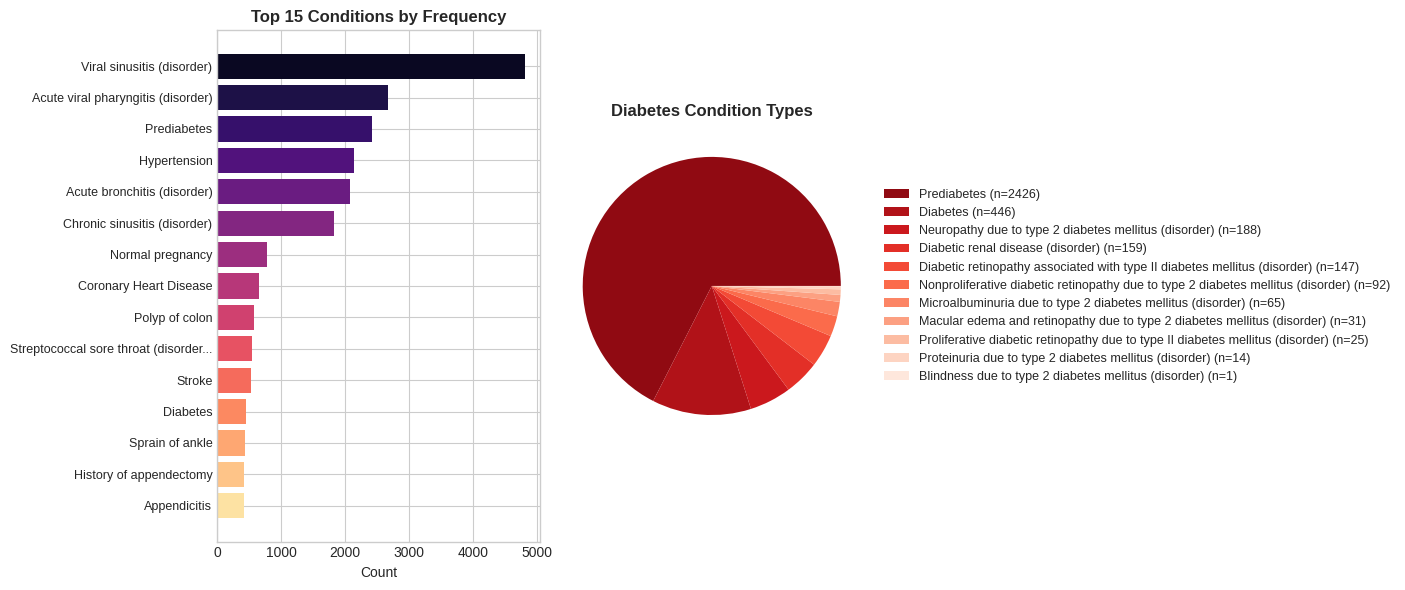

In [46]:
# Conditions visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Plot: Top 15 conditions bar chart ---
ax1 = axes[0]
top_conditions = conditions[cond_desc_col].value_counts().head(15)
colors = sns.color_palette("magma", len(top_conditions))

# TODO: Create horizontal bar chart using ax1.barh()
ax1.barh(top_conditions.index, top_conditions.values, color=colors)

ax1.set_yticks(range(len(top_conditions)))
ax1.set_yticklabels([c[:35] + '...' if len(c) > 35 else c for c in top_conditions.index], fontsize=9)
ax1.set_xlabel('Count')
ax1.set_title('Top 15 Conditions by Frequency', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# --- Right Plot: Diabetes conditions pie chart ---
ax2 = axes[1]
diabetes_conditions = conditions[diabetes_mask][cond_desc_col].value_counts()

if len(diabetes_conditions) > 0:
    colors_dm = sns.color_palette("Reds_r", len(diabetes_conditions))

    # TODO: Create pie chart using ax2.pie()
    ax2.pie(diabetes_conditions, colors=colors_dm)

    # Add counts to legend labels
    legend_labels = [f'{name} (n={count})' for name, count in diabetes_conditions.items()]
    ax2.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)

    ax2.set_title('Diabetes Condition Types', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Task C.2: Observations Analysis (Labs & Vitals)

### Aim
Analyze the distribution of lab values and vital signs, focusing on HbA1c for diabetes management.

### HbA1c Reference Ranges
- **< 7%**: Good control (target for most patients)
- **7-9%**: Suboptimal control (increased risk)
- **> 9%**: Poor control (high risk of complications)

In [47]:
# Observations analysis
obs_patient_col = get_col(observations, 'patient')
obs_desc_col = get_col(observations, 'description')
obs_value_col = get_col(observations, 'value')

print("OBSERVATIONS ANALYSIS")
print("=" * 50)
print(f"Total observation records: {len(observations):,}")
print(f"Unique patients with observations: {observations[obs_patient_col].nunique():,}")
print(f"Unique observation types: {observations[obs_desc_col].nunique():,}")

print(f"\nTop 10 Observation Types:")
print(observations[obs_desc_col].value_counts().head(10).to_string())

# HbA1c analysis
hba1c_mask = observations[obs_desc_col].str.contains('A1c|Hemoglobin A1c', case=False, na=False)
hba1c_values = observations[hba1c_mask][obs_value_col].dropna()
hba1c_numeric = pd.to_numeric(hba1c_values, errors='coerce').dropna()
hba1c_numeric = hba1c_numeric[(hba1c_numeric >= 4) & (hba1c_numeric <= 15)]
hba1c_patient_ids = observations[hba1c_mask][obs_patient_col].unique()

print(f"\n" + "=" * 50)
print("HbA1c ANALYSIS")
print("=" * 50)
print(f"HbA1c records: {len(hba1c_numeric):,}")
print(f"Patients with HbA1c: {len(hba1c_patient_ids):,}")
print(f"\nHbA1c Distribution:")
print(f"  Mean: {hba1c_numeric.mean():.2f}%")
print(f"  Median: {hba1c_numeric.median():.2f}%")
print(f"  Min: {hba1c_numeric.min():.2f}%")
print(f"  Max: {hba1c_numeric.max():.2f}%")
print(f"\nControl Categories:")
print(f"  Good (<7%): {(hba1c_numeric < 7).sum():,} ({(hba1c_numeric < 7).sum()/len(hba1c_numeric)*100:.1f}%)")
print(f"  Suboptimal (7-9%): {((hba1c_numeric >= 7) & (hba1c_numeric <= 9)).sum():,}")
print(f"  Poor (>9%): {(hba1c_numeric > 9).sum():,} ({(hba1c_numeric > 9).sum()/len(hba1c_numeric)*100:.1f}%)")

OBSERVATIONS ANALYSIS
Total observation records: 345,083
Unique patients with observations: 7,605
Unique observation types: 64

Top 10 Observation Types:
DESCRIPTION
Diastolic Blood Pressure                    37758
Systolic Blood Pressure                     37758
Body Height                                 33558
Body Weight                                 33558
Body Mass Index                             32634
Hemoglobin A1c/Hemoglobin.total in Blood    24430
Glucose                                     10431
Urea Nitrogen                               10431
Creatinine                                  10431
Calcium                                     10431

HbA1c ANALYSIS
HbA1c records: 23,698
Patients with HbA1c: 2,126

HbA1c Distribution:
  Mean: 6.97%
  Median: 6.20%
  Min: 4.00%
  Max: 14.00%

Control Categories:
  Good (<7%): 18,634 (78.6%)
  Suboptimal (7-9%): 1,932
  Poor (>9%): 3,132 (13.2%)


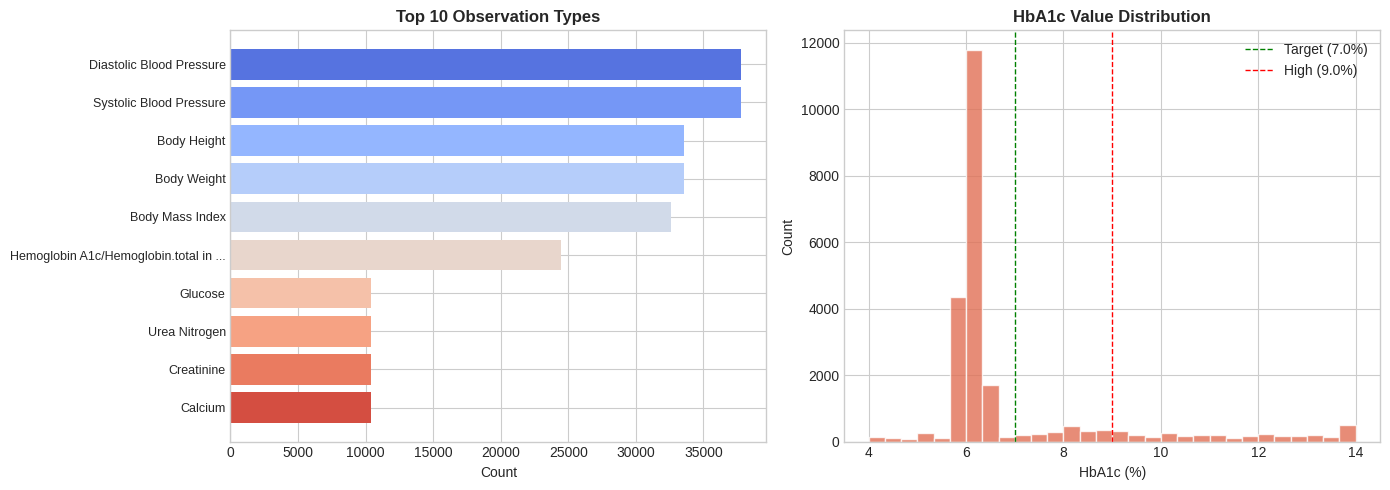

In [50]:
# Observations visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Top 10 observation types ---
ax1 = axes[0]
top_obs = observations[obs_desc_col].value_counts().head(10)
colors = sns.color_palette("coolwarm", len(top_obs))

# TODO: Create horizontal bar chart using ax1.barh()
ax1.barh(top_obs.index, top_obs.values, color=colors)

ax1.set_yticks(range(len(top_obs)))
ax1.set_yticklabels([o[:35] + '...' if len(o) > 35 else o for o in top_obs.index], fontsize=9)
ax1.set_xlabel('Count')
ax1.set_title('Top 10 Observation Types', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# --- Right Plot: HbA1c distribution histogram ---
ax2 = axes[1]
if len(hba1c_numeric) > 0:
    ax2.hist(hba1c_numeric, bins=30, color='#E17055', edgecolor='white', alpha=0.8)

    # TODO: Add vertical reference lines at 7.0 and 9.0 using ax2.axvline()
    ax2.axvline(7.0, color='green', linestyle='--', linewidth=1, label='Target (7.0%)')
    ax2.axvline(9.0, color='red', linestyle='--', linewidth=1, label='High (9.0%)')


    ax2.set_xlabel('HbA1c (%)')
    ax2.set_ylabel('Count')
    ax2.set_title('HbA1c Value Distribution', fontsize=12, fontweight='bold')
    ax2.legend()

plt.tight_layout()
plt.show()

## Task C.3: Patient Data Coverage

### Aim
Measure what percentage of patients have each type of data.

### Why Coverage Matters
- **Missing data** requires imputation or model adjustments
- **Low coverage** data types may not be usable as features
- **Coverage gaps** may indicate systematic data quality issues

We want **>80% coverage** for key data types.

In [51]:
# Calculate coverage
total_patients = len(patients)

coverage = {
    'encounters': encounters[get_col(encounters, 'patient')].nunique(),
    'conditions': conditions[get_col(conditions, 'patient')].nunique(),
    'medications': medications[get_col(medications, 'patient')].nunique(),
    'observations': observations[get_col(observations, 'patient')].nunique(),
    'procedures': procedures[get_col(procedures, 'patient')].nunique(),
    'allergies': allergies[get_col(allergies, 'patient')].nunique()
}

print("PATIENT DATA COVERAGE")
print("=" * 50)
print(f"Total patients: {total_patients:,}")
print(f"\nPatients with data in each table:")
for table, count in coverage.items():
    pct = count / total_patients * 100
    status = "Good" if pct >= 80 else "Moderate" if pct >= 50 else "Low"
    print(f"  {table}: {count:,} ({pct:.1f}%) - {status}")

PATIENT DATA COVERAGE
Total patients: 9,998

Patients with data in each table:
  encounters: 7,629 (76.3%) - Moderate
  conditions: 7,395 (74.0%) - Moderate
  medications: 6,881 (68.8%) - Moderate
  observations: 7,605 (76.1%) - Moderate
  procedures: 6,337 (63.4%) - Moderate
  allergies: 800 (8.0%) - Low


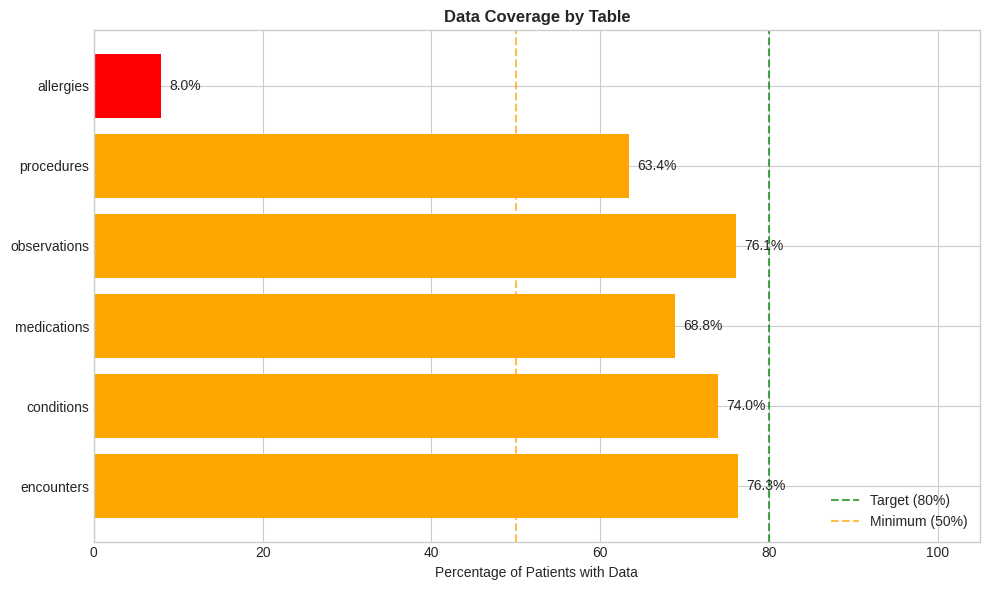

In [52]:
# Coverage visualization
fig, ax = plt.subplots(figsize=(10, 6))

coverage_pct = {k: v / total_patients * 100 for k, v in coverage.items()}
tables_list = list(coverage_pct.keys())
pcts = list(coverage_pct.values())

# TODO: Create color list - green for >=80%, orange for >=50%, red for <50%
# Hint: Use list comprehension with conditional color assignment
colors = ['green' if pct >= 80 else 'orange' if pct >= 50 else 'red' for pct in pcts]

bars = ax.barh(tables_list, pcts, color=colors if colors else '#3498db')

ax.axvline(80, color='green', linestyle='--', alpha=0.7, label='Target (80%)')
ax.axvline(50, color='orange', linestyle='--', alpha=0.7, label='Minimum (50%)')

ax.set_xlabel('Percentage of Patients with Data')
ax.set_title('Data Coverage by Table', fontsize=12, fontweight='bold')
ax.set_xlim(0, 105)
ax.legend(loc='lower right')

for bar, pct in zip(bars, pcts):
    ax.text(pct + 1, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---

# Section D: Data Quality Assessment (Optional)

## Why This Section Matters

Data quality assessment is **essential for any ML project**. Before building models, you need to:

| Task | Purpose |
|------|---------|
| **Quantify completeness** | How complete is each patient's record? |
| **Identify critical gaps** | What's missing that could affect model performance? |
| **Document findings** | Create an auditable record for stakeholders |

> **Note:** Document data quality issues BEFORE building models. This prevents debugging headaches later and demonstrates professional rigor.

## Task D.1: Per-Patient Coverage Metrics

### Aim
Build a DataFrame with coverage metrics for each patient.

### Questions to Answer
1. Which patient has the most encounters?
2. How many patients have zero conditions?
3. What percentage of patients have medications?

In [53]:
# Build per-patient coverage DataFrame
patient_id_col = get_col(patients, 'id')

coverage_df = pd.DataFrame({
    'patient_id': patients[patient_id_col]
})

# Count records per patient for each table
coverage_df['num_encounters'] = coverage_df['patient_id'].map(
    encounters.groupby(get_col(encounters, 'patient')).size()
).fillna(0).astype(int)

coverage_df['num_conditions'] = coverage_df['patient_id'].map(
    conditions.groupby(get_col(conditions, 'patient')).size()
).fillna(0).astype(int)

coverage_df['num_medications'] = coverage_df['patient_id'].map(
    medications.groupby(get_col(medications, 'patient')).size()
).fillna(0).astype(int)

coverage_df['num_observations'] = coverage_df['patient_id'].map(
    observations.groupby(get_col(observations, 'patient')).size()
).fillna(0).astype(int)

print("PER-PATIENT COVERAGE")
print("=" * 50)
print(coverage_df.describe().to_string())

PER-PATIENT COVERAGE
       num_encounters  num_conditions  num_medications  num_observations
count     9998.000000     9998.000000      9998.000000       9998.000000
mean         7.355871        3.159532         2.519504         34.515203
std          9.108648        2.742683         3.445944         39.553838
min          0.000000        0.000000         0.000000          0.000000
25%          1.000000        0.000000         0.000000          1.000000
50%          7.000000        3.000000         2.000000         25.000000
75%         11.000000        5.000000         4.000000         46.000000
max        101.000000       25.000000        87.000000        205.000000


In [54]:
# Answer the questions
print("=" * 50)
print("ANSWERS")
print("=" * 50)

# Q1: Patient with most encounters
max_enc_patient = coverage_df.loc[coverage_df['num_encounters'].idxmax()]
print(f"\n1. Patient with most encounters:")
print(f"   ID: {max_enc_patient['patient_id']}")
print(f"   Encounters: {max_enc_patient['num_encounters']}")

# Q2: Patients with zero conditions
zero_cond = (coverage_df['num_conditions'] == 0).sum()
print(f"\n2. Patients with zero conditions: {zero_cond:,}")

# Q3: Percentage with medications
has_meds = (coverage_df['num_medications'] > 0).sum()
pct_meds = has_meds / len(coverage_df) * 100
print(f"\n3. Patients with medications: {has_meds:,} ({pct_meds:.1f}%)")

ANSWERS

1. Patient with most encounters:
   ID: d138d4b9-2fa5-4c8e-a5fc-52697f9f8777
   Encounters: 101

2. Patients with zero conditions: 2,603

3. Patients with medications: 6,881 (68.8%)


## Task D.2: Data Quality Gaps

### Aim
Identify specific quality issues in the data.

### Questions to Answer
1. How many encounters have no associated conditions?
2. How many diabetic patients have NO HbA1c readings?
3. How many patients have encounters but no observations?

In [55]:
# Q1: Encounters without conditions
enc_ids = set(encounters[get_col(encounters, 'id')].unique())
enc_with_cond = set(conditions[get_col(conditions, 'encounter')].unique())
enc_no_cond = len(enc_ids - enc_with_cond)

# Q2: Diabetic patients without HbA1c
hba1c_patients_set = set(hba1c_patient_ids)
diabetic_patients_set = set(diabetes_patient_ids)
diabetic_no_hba1c = len(diabetic_patients_set - hba1c_patients_set)

# Q3: Patients with encounters but no observations
patients_with_enc = set(encounters[get_col(encounters, 'patient')].unique())
patients_with_obs = set(observations[obs_patient_col].unique())
enc_no_obs = len(patients_with_enc - patients_with_obs)

# Calculate date range and observation spans
enc_date_col = get_col(encounters, 'date')
encounters[enc_date_col] = pd.to_datetime(encounters[enc_date_col], errors='coerce')
min_date = encounters[enc_date_col].min()
max_date = encounters[enc_date_col].max()

patient_spans = encounters.groupby(get_col(encounters, 'patient'))[enc_date_col].agg(['min', 'max'])
patient_spans['span_days'] = (patient_spans['max'] - patient_spans['min']).dt.days
short_span = (patient_spans['span_days'] < 365).sum()

print("=" * 50)
print("DATA QUALITY GAPS")
print("=" * 50)
print(f"\n1. Encounters with no conditions: {enc_no_cond:,} ({enc_no_cond/len(enc_ids)*100:.1f}%)")
print(f"\n2. Diabetic patients without HbA1c: {diabetic_no_hba1c:,} ({diabetic_no_hba1c/len(diabetic_patients_set)*100:.1f}%)")
print(f"\n3. Patients with encounters but no observations: {enc_no_obs:,}")
print(f"\n4. Patients with <1 year observation span: {short_span:,}")

DATA QUALITY GAPS

1. Encounters with no conditions: 52,742 (71.7%)

2. Diabetic patients without HbA1c: 495 (18.9%)

3. Patients with encounters but no observations: 24

4. Patients with <1 year observation span: 1,246


## Task D.3: Data Quality Summary Report

### Aim
Generate a formatted summary report of data quality findings.

In [56]:
print("=" * 70)
print("DATA QUALITY SUMMARY REPORT")
print("=" * 70)

print(f"\nDATASET OVERVIEW")
print(f"  Total Patients: {total_patients:,}")
print(f"  Total Encounters: {len(encounters):,}")
print(f"  Date Range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")

print(f"\nCOVERAGE METRICS")
for table, count in coverage.items():
    pct = count / total_patients * 100
    status = "Good" if pct >= 70 else "Moderate" if pct >= 50 else "Low"
    print(f"  {table}: {pct:.1f}% of patients - {status}")

print(f"\nDIABETES FOCUS")
print(f"  Diabetic patients: {len(diabetic_patients_set):,} ({len(diabetic_patients_set)/total_patients*100:.1f}%)")
print(f"  With HbA1c data: {len(diabetic_patients_set & hba1c_patients_set):,}")
print(f"  Missing HbA1c: {diabetic_no_hba1c:,}")

print(f"\nDATA GAPS")
print(f"  Encounters without conditions: {enc_no_cond:,}")
print(f"  Patients <1 year observation: {short_span:,}")

print(f"\n" + "=" * 70)
print("END OF REPORT")
print("=" * 70)

DATA QUALITY SUMMARY REPORT

DATASET OVERVIEW
  Total Patients: 9,998
  Total Encounters: 73,544
  Date Range: 1926-05-12 to 2017-05-24

COVERAGE METRICS
  encounters: 76.3% of patients - Good
  conditions: 74.0% of patients - Good
  medications: 68.8% of patients - Moderate
  observations: 76.1% of patients - Good
  procedures: 63.4% of patients - Moderate
  allergies: 8.0% of patients - Low

DIABETES FOCUS
  Diabetic patients: 2,621 (26.2%)
  With HbA1c data: 2,126
  Missing HbA1c: 495

DATA GAPS
  Encounters without conditions: 52,742
  Patients <1 year observation: 1,246

END OF REPORT


---

# Summary & Next Steps

## What You Accomplished

### Required Sections
- **Section A**: Learned the `ExtendedPatientProfile` class and temporal safety concepts
- **Section B**: Built clinical note extraction functions and processed notes in batch

### Optional Sections
- **Section C**: Explored conditions, observations, medications, and patient data coverage
- **Section D**: Assessed data quality gaps and generated a quality report

## Key Takeaways

1. **Temporal safety** is critical for ML on time-series patient data - always use `cutoff_time`
2. **Clinical notes** contain valuable information not captured in structured tables
3. **Regex patterns** can extract structured data from unstructured text
4. **Data quality assessment** should happen BEFORE model building

## Next Steps (Week 2)

With this foundation, you're ready for Week 2 where you'll:

1. **Implement `get_daily_features(cutoff_time)`** - The core feature engineering method
2. **Train a binary classifier** - Predict 30-day high-risk events
3. **Build an agentic monitoring system** - Automated alerts for high-risk patients

---

## Homework Submission Checklist

Before submitting, confirm that your work is complete and reproducible.

### Required (Sections A & B)
- [ ] Notebook runs **end-to-end** without errors
- [ ] `ExtendedPatientProfile` example is populated with conditions, HbA1c readings, and encounters
- [ ] All extraction functions are defined and tested (`extract_vitals_from_note`, `extract_labs_from_note`, `extract_medications_from_note`, `extract_all_from_note`)
- [ ] Clinical notes are processed in batch with extraction summary printed
- [ ] Extracted DataFrames are created (labs, medications, vitals)
- [ ] Merge function combines extracted data with original CSVs

### Optional (Sections C & D)
- [ ] Conditions analysis with diabetes prevalence calculated
- [ ] Visualizations for conditions, observations, medications
- [ ] Coverage metrics calculated for all tables
- [ ] Per-patient coverage DataFrame created
- [ ] Data quality gaps identified and quantified
- [ ] Quality summary report generated

> **Common pitfalls to avoid:**
> - Hard-coded file paths that only work on your machine
> - Missing variable definitions (e.g., using `obs_desc_col` before defining it)
> - Outputs not showing due to missing `print()` statements